In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape,Input

In [2]:
# Data Load
data = pd.read_excel("data/data.xlsx")
print("Data Shape : {}".format(data.shape))

Data Shape : (687, 6)


In [3]:
data.describe()

,Time,Y1,Y2,Y3,Y4,Label
count,687.000000,687.000000,687.000000,687.000000,687.000000,687.000000
mean,344.000000,5.035127,50.997501,25.396162,50.535352,0.016012
std,198.464103,0.130613,1.413051,0.602280,1.141266,0.125611
min,1.000000,4.692480,47.683200,24.475200,47.961600,0.000000
25%,172.500000,4.976500,50.395000,25.130000,50.005000,0.000000
50%,344.000000,5.025000,50.870000,25.345000,50.480000,0.000000
75%,515.500000,5.077500,51.365000,25.567500,50.930000,0.000000
max,687.000000,6.205200,63.396000,30.888000,61.368000,1.000000


In [ ]:
# 11 fraud cases out of 687 case.
data[data['Label'] == 1]
print(len(data[data['Label'] == 1]))

11


In [5]:
data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687 entries, 0 to 686
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    687 non-null    int64  
 1   Y1      687 non-null    float64
 2   Y2      687 non-null    float64
 3   Y3      687 non-null    float64
 4   Y4      687 non-null    float64
 5   Label   687 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 32.3 KB


In [7]:
# Check Missing data
col = []
missing = []
for name in data.columns:
    # Missing
    missper = data[name].isnull().sum() / data.shape[0]
    missing.append(round(missper, 4))

In [8]:
data.columns # Don't know about the variables.

Index(['Time', 'Y1', 'Y2', 'Y3', 'Y4', 'Label'], dtype='object')

In [9]:
missing

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [10]:
# Unique values Check
col = []
level = [] 
for name in data.columns:
    
    # Leveling
    lel = data[name].dropna() 
    level.append(len(list(set(lel))))

    # Columns
    col.append(name)

In [11]:
# Data Missing에 대해 DataFrame을 만들어줌
summary = pd.concat([pd.DataFrame(col, columns=['name']), 
                     pd.DataFrame(missing, columns=['Missing Percentage']), 
                     pd.DataFrame(level, columns=['Unique'])], axis=1)

In [75]:
summary

,name,Missing Percentage,Unique
0,Time,0.0,687
1,Y1,0.0,273
2,Y2,0.0,259
3,Y3,0.0,266
4,Y4,0.0,250
5,Label,0.0,2


In [12]:
# Data Cutting
drop_col = summary['name'][(summary['Unique'] <= 1) | (summary['Missing Percentage'] >= 0.8)] # If unique is 1 or missing percentage is 80%
data.drop(columns=drop_col, inplace=True)
print(">>>> Data Shape : {}".format(data.shape))

>>>> Data Shape : (687, 6)


In [13]:
len(drop_col)

0

In [14]:
np.percentile(data['Y1'], 20)

4.9652

In [15]:
np.percentile(data['Y1'], 80)

5.087

In [16]:
data['Time'][data['Label'] == 1]

11      12
67      68
136    137
315    316
361    362
476    477
498    499
525    526
612    613
666    667
685    686
Name: Time, dtype: int64

In [17]:
data['Y1'][data['Label'] == 1]


11     6.15480
67     4.69248
136    5.99520
315    5.93520
361    4.80288
476    4.86240
498    6.07800
525    6.05880
612    5.97480
666    6.20520
685    5.94480
Name: Y1, dtype: float64

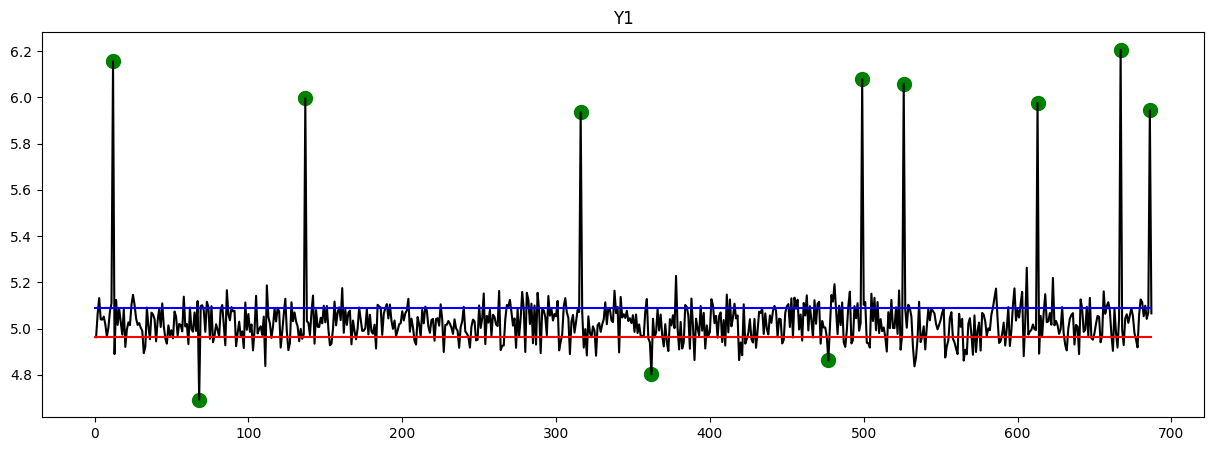

In [18]:
# Y1 Plot
plt.figure(figsize=(15,5)) # Plot size
plt.plot(data['Time'], data['Y1'], c='black') # data는 time과 y1 데이터. time의 흐름에 따른 y1의 변화를 나타냄
plt.plot([0, data.shape[0]], [np.percentile(data['Y1'], 20), np.percentile(data['Y1'], 20)],c='red') # 20% 분위수를 빨간색으로 선긋고
plt.plot([0, data.shape[0]], [np.percentile(data['Y1'], 80), np.percentile(data['Y1'], 80)],c='blue') # 80% 분위수를 파란색으로 선긋고
plt.scatter(data['Time'][data['Label'] == 1], data['Y1'][data['Label'] == 1], s=100, c='green') # 레이블이 1인 데이터를 녹색으로 표시. 딱 봐도 20%와 80% 분위수를 넘어서는 곳에
plt.title("Y1")
plt.show()

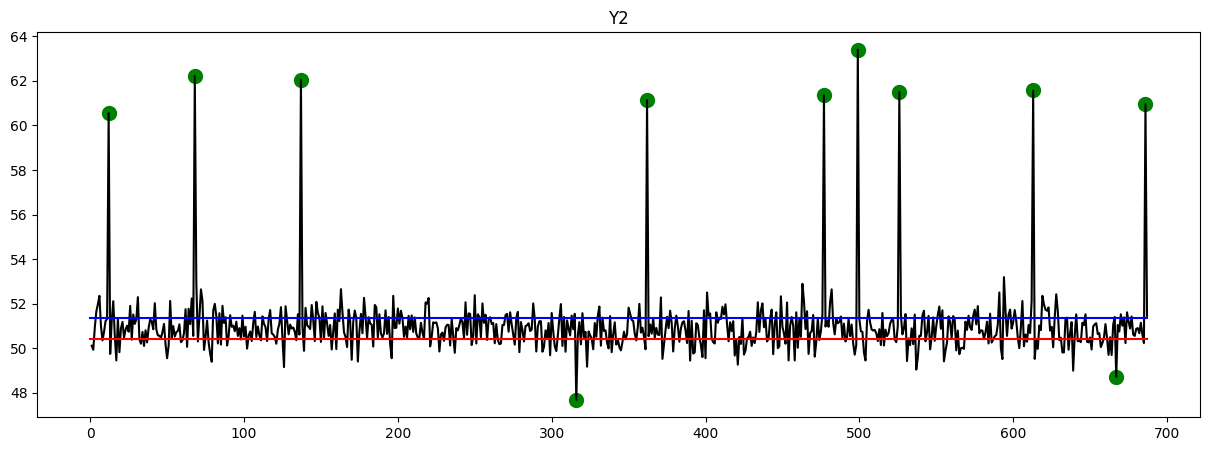

In [19]:
# Y2 Plot
plt.figure(figsize=(15,5))
plt.plot(data['Time'], data['Y2'], c='black')
plt.plot([0, data.shape[0]], [np.percentile(data['Y2'], 25), np.percentile(data['Y2'], 25)],c='red')
plt.plot([0, data.shape[0]], [np.percentile(data['Y2'], 75), np.percentile(data['Y2'], 75)],c='blue')
plt.scatter(data['Time'][data['Label'] == 1], data['Y2'][data['Label'] == 1], s=100, c='green')
plt.title("Y2")
plt.show()

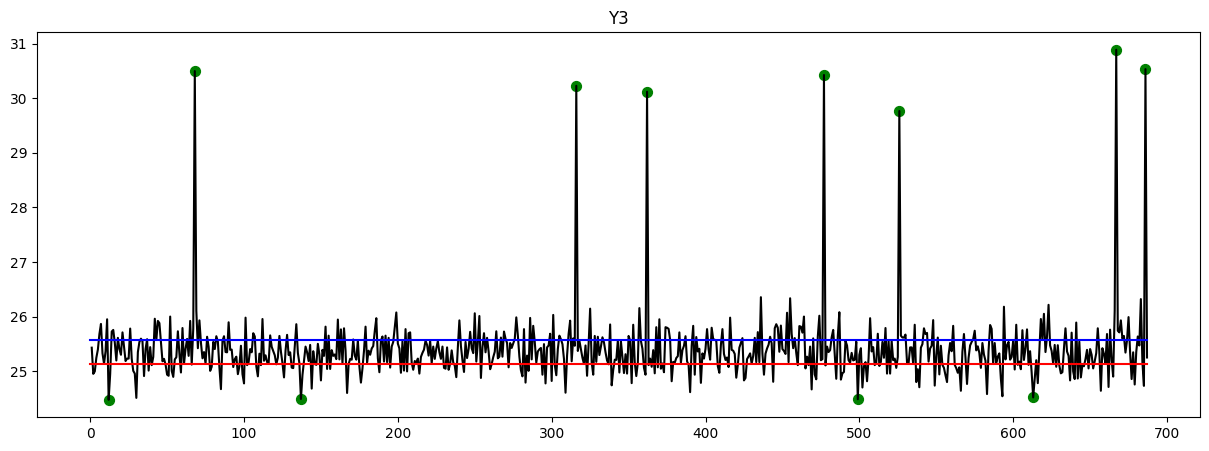

In [20]:
# Y3 Plot
plt.figure(figsize=(15,5))
plt.plot(data['Time'], data['Y3'], c='black')
plt.plot([0, data.shape[0]], [np.percentile(data['Y3'], 25), np.percentile(data['Y3'], 25)],c='red')
plt.plot([0, data.shape[0]], [np.percentile(data['Y3'], 75), np.percentile(data['Y3'], 75)],c='blue')
plt.scatter(data['Time'][data['Label'] == 1], data['Y3'][data['Label'] == 1], s=50, c='green')
plt.title("Y3")
plt.show()

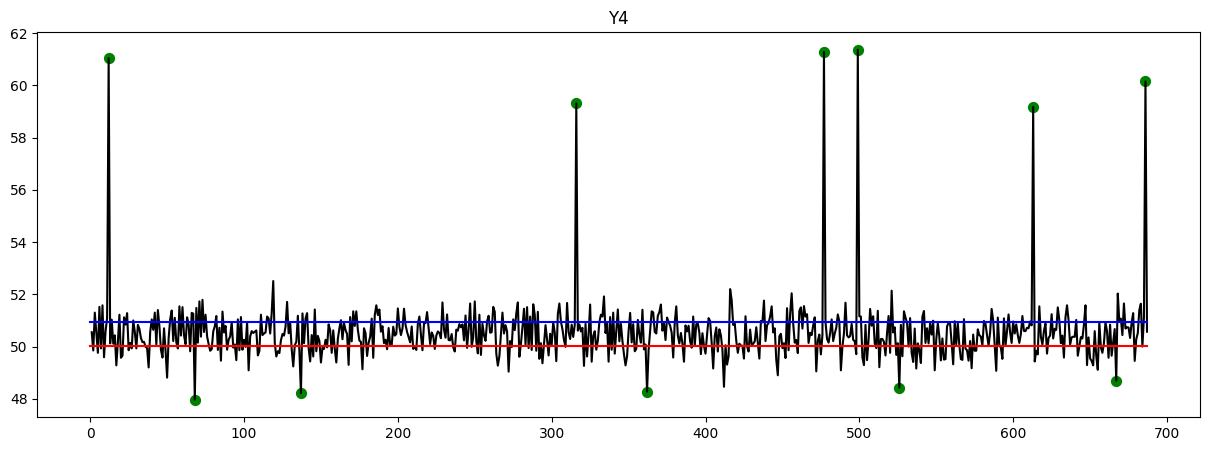

In [21]:
# Y4 Plot
plt.figure(figsize=(15,5))
plt.plot(data['Time'], data['Y4'], c='black')
plt.plot([0, data.shape[0]], [np.percentile(data['Y4'], 25), np.percentile(data['Y4'], 25)],c='red')
plt.plot([0, data.shape[0]], [np.percentile(data['Y4'], 75), np.percentile(data['Y4'], 75)],c='blue')
plt.scatter(data['Time'][data['Label'] == 1], data['Y4'][data['Label'] == 1], s=50, c='green')
plt.title("Y4")
plt.show()

In [22]:
# Train Valid Split
# 데이터가 작기때문에 데이터를 그냥 나누어줌
# 현실에서는 Index Play 필수
# Train Valid split 시 시간에 따른 스플릿 필요
train_idx = list(range(int(data.shape[0]*0.7)))
valid_idx = list(range(int(data.shape[0]*0.7), data.shape[0]))

In [25]:
data

,Time,Y1,Y2,Y3,Y4,Label
0,1,4.9630,50.11,25.430,50.550,0
1,2,5.0630,49.93,24.950,49.850,0
2,3,5.1320,50.93,24.995,51.300,0
3,4,5.0400,51.65,25.245,50.520,0
4,5,5.0390,51.97,25.395,49.760,0
...,...,...,...,...,...,...
682,683,5.0990,51.14,26.320,51.640,0
683,684,5.0420,50.61,25.170,50.000,0
684,685,5.0710,50.23,24.730,51.110,0
685,686,5.9448,60.96,30.534,60.156,1


In [26]:
data['Label'].iloc[train_idx] == 1

0      False
1      False
2      False
3      False
4      False
       ...  
475    False
476     True
477    False
478    False
479    False
Name: Label, Length: 480, dtype: bool

In [27]:
x_train = data.iloc[train_idx,1:-1]
x_valid = data.iloc[valid_idx,1:-1]

In [28]:
x_train

,Y1,Y2,Y3,Y4
0,4.9630,50.110,25.430,50.550
1,5.0630,49.930,24.950,49.850
2,5.1320,50.930,24.995,51.300
3,5.0400,51.650,25.245,50.520
4,5.0390,51.970,25.395,49.760
...,...,...,...,...
475,4.9640,51.520,25.220,50.440
476,4.8624,61.356,30.426,61.284
477,5.0030,50.970,25.105,50.940
478,5.1450,51.250,25.450,50.290


In [29]:
x_valid

,Y1,Y2,Y3,Y4
480,5.1920,52.08,25.385,50.510
481,5.0850,52.64,25.620,51.040
482,4.9760,51.12,25.755,50.210
483,5.0990,50.62,25.310,50.500
484,5.0150,51.31,24.860,50.720
...,...,...,...,...
682,5.0990,51.14,26.320,51.640
683,5.0420,50.61,25.170,50.000
684,5.0710,50.23,24.730,51.110
685,5.9448,60.96,30.534,60.156


In [30]:
# This is the dimension of the latent space (encoding space)
latent_dim = 1 # 4차원 포인트를 1차원 벡터로 압축.

# input size 4개
data_shape = x_train.shape[1] # 입력 데이터의 크기, --> 4개

encoder = Sequential([ # 인코더 모델 생성
    Input(shape=data_shape), # 입력 데이터의 크기
    Dense(2, activation='relu'), # 첫번째 레이어, 2개의 뉴런, relu 활성화 함수  
    Dense(latent_dim, name='encoder_output')]) # 두번째 레이어, 잠재공간의 차원, 이름 지정 

decoder = Sequential([ # 디코더 모델 생성
    Dense(2, activation='relu', input_shape=(latent_dim,)), # 첫번째 레이어, 2개의 뉴런, relu 활성화 함수, 입력 데이터의 크기
    Dense(data_shape)]) # 두번째 레이어, 입력 데이터의 크기

In [31]:
autoencoder = Model(inputs=encoder.input, outputs=decoder(encoder.output))

In [32]:
autoencoder.summary() 

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense (Dense)               (None, 2)                 10        
                                                                 
 encoder_output (Dense)      (None, 1)                 3         
                                                                 
 sequential_1 (Sequential)   (None, 4)                 16        
                                                                 
Total params: 29 (116.00 Byte)
Trainable params: 29 (116.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [33]:
autoencoder.compile(loss='mean_squared_error', optimizer='adam')
autoencoder.fit(x_train, x_train, epochs=100, batch_size=10, validation_data=(x_valid, x_valid))

Epoch 1/100
48/48 [==============================] - 1s 4ms/step - loss: 1780.4241 - val_loss: 1641.3357
Epoch 2/100
48/48 [==============================] - 0s 1ms/step - loss: 1558.6141 - val_loss: 1493.6709
Epoch 3/100
48/48 [==============================] - 0s 2ms/step - loss: 1450.7866 - val_loss: 1417.0920
Epoch 4/100
48/48 [==============================] - 0s 2ms/step - loss: 1390.6018 - val_loss: 1368.5273
Epoch 5/100
48/48 [==============================] - 0s 1ms/step - loss: 1345.5306 - val_loss: 1324.1013
Epoch 6/100
48/48 [==============================] - 0s 1ms/step - loss: 1298.0320 - val_loss: 1272.0275
Epoch 7/100
48/48 [==============================] - 0s 1ms/step - loss: 1239.9226 - val_loss: 1206.6892
Epoch 8/100
48/48 [==============================] - 0s 1ms/step - loss: 1165.7045 - val_loss: 1121.4406
Epoch 9/100
48/48 [==============================] - 0s 1ms/step - loss: 1065.1885 - val_loss: 1001.4910
Epoch 10/100
48/48 [==============================] - 0

In [34]:
encoder_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('encoder_output').output)

In [35]:
encoder_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense (Dense)               (None, 2)                 10        
                                                                 
 encoder_output (Dense)      (None, 1)                 3         
                                                                 
Total params: 13 (52.00 Byte)
Trainable params: 13 (52.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
dim_1 = encoder_model.predict(data.iloc[:,1:-1])

22/22 [==============================] - 0s 685us/step


In [37]:
dim_1

array([[-113.31002 ],
       [-112.280876],
       [-114.62955 ],
       [-115.09896 ],
       [-115.00734 ],
       [-116.95313 ],
       [-114.17333 ],
       [-114.32892 ],
       [-113.198975],
       [-114.66744 ],
       [-115.45571 ],
       [-133.47408 ],
       [-112.28903 ],
       [-115.1883  ],
       [-115.640945],
       [-113.78767 ],
       [-111.38876 ],
       [-114.67623 ],
       [-113.4077  ],
       [-113.49172 ],
       [-114.112076],
       [-114.19641 ],
       [-114.287605],
       [-114.845314],
       [-113.42918 ],
       [-115.39211 ],
       [-113.05385 ],
       [-115.164246],
       [-114.28681 ],
       [-113.8393  ],
       [-116.20073 ],
       [-113.83073 ],
       [-113.34704 ],
       [-113.82919 ],
       [-112.73395 ],
       [-113.7419  ],
       [-113.09437 ],
       [-113.05113 ],
       [-114.773186],
       [-114.87913 ],
       [-114.197   ],
       [-116.51373 ],
       [-113.92577 ],
       [-114.74657 ],
       [-114.27121 ],
       [-1

In [38]:
data['dim_1'] = - (dim_1)

In [39]:
data['dim_1']

0      113.310020
1      112.280876
2      114.629547
3      115.098961
4      115.007339
          ...    
682    115.853622
683    113.365974
684    113.486038
685    136.558075
686    114.882317
Name: dim_1, Length: 687, dtype: float32

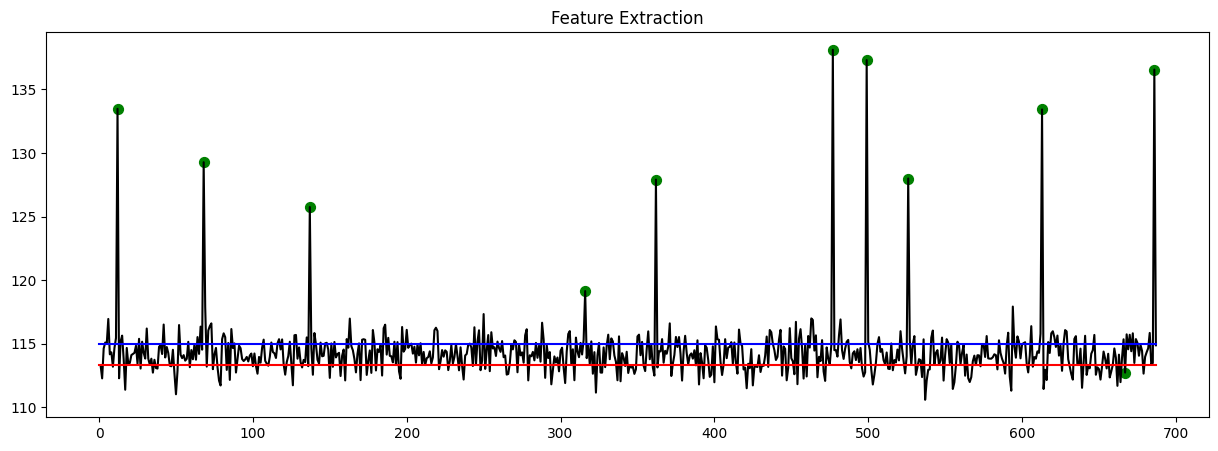

In [40]:
# dim_1 Plotting
plt.figure(figsize=(15,5))
plt.plot(data['Time'], data['dim_1'], c='black')
plt.plot([0, data.shape[0]], [np.percentile(data['dim_1'], 25), np.percentile(data['dim_1'], 25)],c='red')
plt.plot([0, data.shape[0]], [np.percentile(data['dim_1'], 75), np.percentile(data['dim_1'], 75)],c='blue')
plt.scatter(data['Time'][data['Label'] == 1], data['dim_1'][data['Label'] == 1], s=50, c='green')
plt.title("Feature Extraction")
plt.show()

In [41]:
data

,Time,Y1,Y2,Y3,Y4,Label,dim_1
0,1,4.9630,50.11,25.430,50.550,0,113.310020
1,2,5.0630,49.93,24.950,49.850,0,112.280876
2,3,5.1320,50.93,24.995,51.300,0,114.629547
3,4,5.0400,51.65,25.245,50.520,0,115.098961
4,5,5.0390,51.97,25.395,49.760,0,115.007339
...,...,...,...,...,...,...,...
682,683,5.0990,51.14,26.320,51.640,0,115.853622
683,684,5.0420,50.61,25.170,50.000,0,113.365974
684,685,5.0710,50.23,24.730,51.110,0,113.486038
685,686,5.9448,60.96,30.534,60.156,1,136.558075


In [42]:
# LOF Setup - Local Outlier Factor. 하나의 score로 표현됨.
LOF = LocalOutlierFactor(n_neighbors=5) #LOF --> 이상치 탐지 알고리즘, data's local density를 고려하여 이상치 탐지
y_pred = LOF.fit_predict(data.iloc[:, 1:-2])

In [43]:
y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [ ]:
for i in range(y_pred.shape[0]):
    if y_pred[i] == 1:
        y_pred[i] = 0
    else:
        y_pred[i] = 1

n_errors = (y_pred != data['Label']).sum() # 21
X_scores = LOF.negative_outlier_factor_

In [45]:
data['lof'] = y_pred

In [46]:
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min()) 

In [47]:
data['lof_score']=radius

In [48]:
data

,Time,Y1,Y2,Y3,Y4,Label,dim_1,lof,lof_score
0,1,4.9630,50.11,25.430,50.550,0,113.310020,0,0.006702
1,2,5.0630,49.93,24.950,49.850,0,112.280876,0,0.005950
2,3,5.1320,50.93,24.995,51.300,0,114.629547,0,0.023519
3,4,5.0400,51.65,25.245,50.520,0,115.098961,0,0.008254
4,5,5.0390,51.97,25.395,49.760,0,115.007339,0,0.013839
...,...,...,...,...,...,...,...,...,...
682,683,5.0990,51.14,26.320,51.640,0,115.853622,1,0.043580
683,684,5.0420,50.61,25.170,50.000,0,113.365974,0,0.004379
684,685,5.0710,50.23,24.730,51.110,0,113.486038,0,0.023241
685,686,5.9448,60.96,30.534,60.156,1,136.558075,0,0.007993


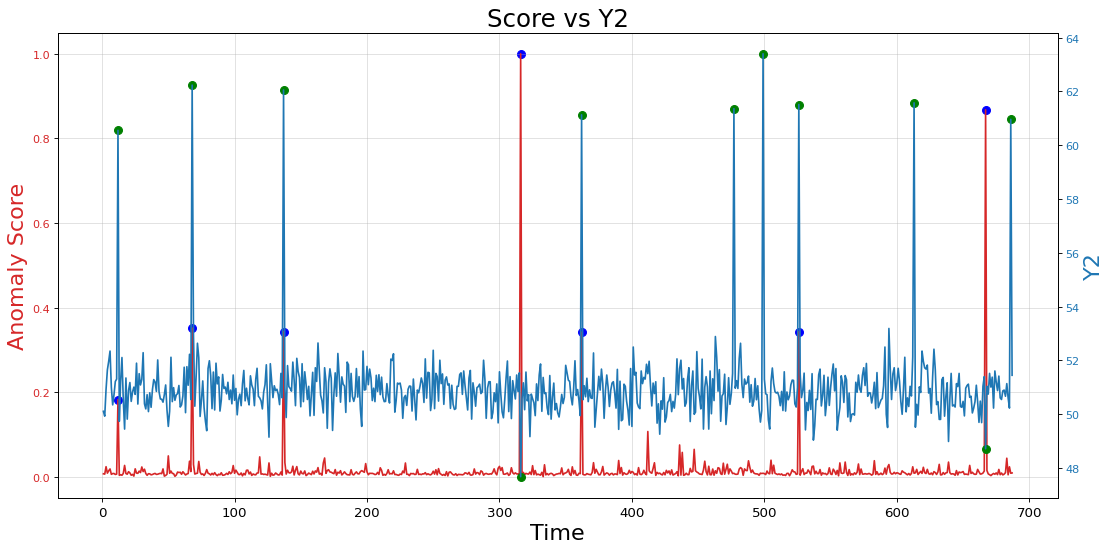

In [111]:
# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(14,7), dpi= 80) # dpi는 해상도.
ax1.plot(data['Time'], radius, color='tab:red') # 빨간색으로 플롯
ax1.scatter(data['Time'][data['lof_score'] >= 0.18], data['lof_score'][data['lof_score'] >= 0.18], s=50, c='blue') # 파란색으로 플롯

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(data['Time'], data['Y2'], color='tab:blue')
ax2.scatter(data['Time'][data['Label'] == 1], data['Y2'][data['Label'] == 1], s=50, c='green')

# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('Anomaly Score', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("Y2", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_title("Score vs Y2", fontsize=22)
fig.tight_layout()
plt.show()

In [112]:
data

,Time,Y1,Y2,Y3,Y4,Label,dim_1,lof,lof_score
0,1,4.9630,50.11,25.430,50.550,0,-0.0,0,0.006702
1,2,5.0630,49.93,24.950,49.850,0,-0.0,0,0.005950
2,3,5.1320,50.93,24.995,51.300,0,-0.0,0,0.023519
3,4,5.0400,51.65,25.245,50.520,0,-0.0,0,0.008254
4,5,5.0390,51.97,25.395,49.760,0,-0.0,0,0.013839
...,...,...,...,...,...,...,...,...,...
682,683,5.0990,51.14,26.320,51.640,0,-0.0,1,0.043580
683,684,5.0420,50.61,25.170,50.000,0,-0.0,0,0.004379
684,685,5.0710,50.23,24.730,51.110,0,-0.0,0,0.023241
685,686,5.9448,60.96,30.534,60.156,1,-0.0,0,0.007993


In [113]:
# Isolation Forest Setup
IF = IsolationForest(n_estimators = 50, max_samples = 600)
IF.fit(data[['Y1', 'Y2', 'Y3', 'Y4']])
y_pred = IF.predict(data[['Y1', 'Y2', 'Y3', 'Y4']])

for i in range(y_pred.shape[0]):
    if y_pred[i] == 1:
        y_pred[i] = 0
    else:
        y_pred[i] = 1
X_scores = IF.score_samples(data[['Y1', 'Y2', 'Y3', 'Y4']])

In [114]:
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

In [115]:
data['IF'] = y_pred
data['IF_score'] = radius

In [116]:
data

,Time,Y1,Y2,Y3,Y4,Label,dim_1,lof,lof_score,IF,IF_score
0,1,4.9630,50.11,25.430,50.550,0,-0.0,0,0.006702,0,0.081653
1,2,5.0630,49.93,24.950,49.850,0,-0.0,0,0.005950,0,0.110344
2,3,5.1320,50.93,24.995,51.300,0,-0.0,0,0.023519,0,0.152744
3,4,5.0400,51.65,25.245,50.520,0,-0.0,0,0.008254,0,0.043350
4,5,5.0390,51.97,25.395,49.760,0,-0.0,0,0.013839,0,0.147906
...,...,...,...,...,...,...,...,...,...,...,...
682,683,5.0990,51.14,26.320,51.640,0,-0.0,1,0.043580,1,0.363031
683,684,5.0420,50.61,25.170,50.000,0,-0.0,0,0.004379,0,0.027248
684,685,5.0710,50.23,24.730,51.110,0,-0.0,0,0.023241,0,0.232406
685,686,5.9448,60.96,30.534,60.156,1,-0.0,0,0.007993,1,0.900804


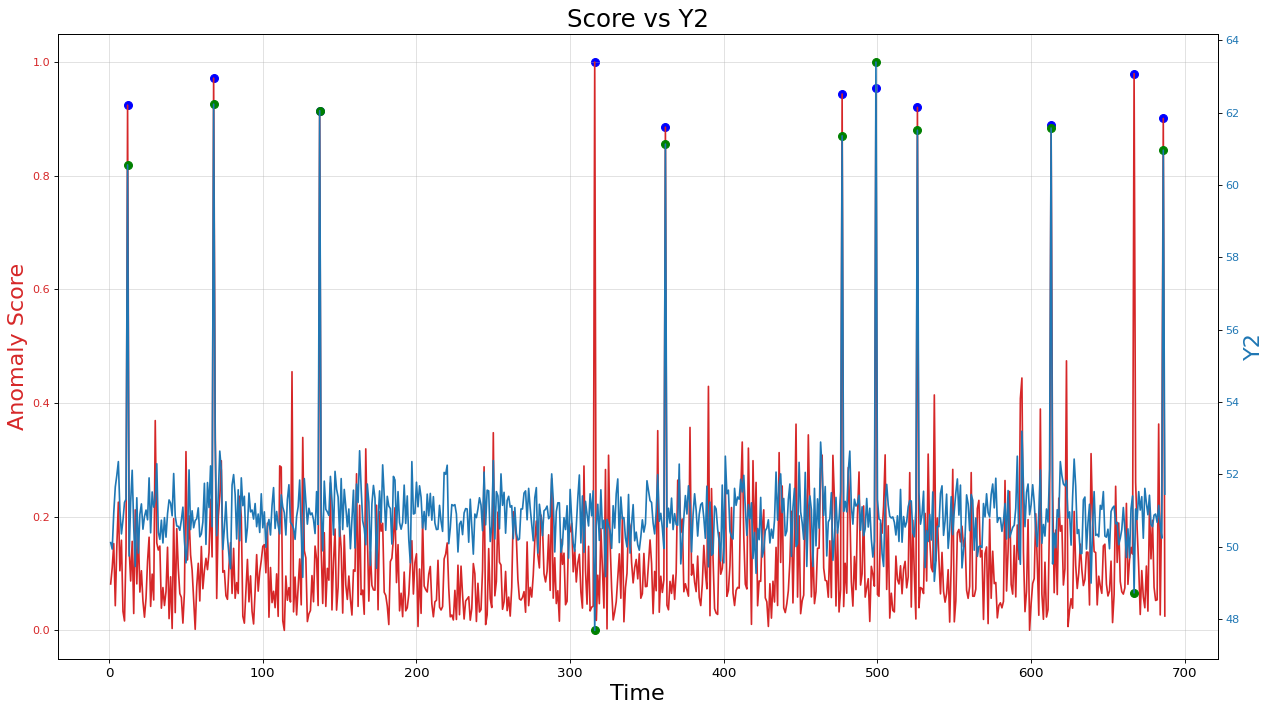

In [117]:
# Plot Line1 (Left Y Axis)
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)
ax1.plot(data['Time'], radius, color='tab:red')
ax1.scatter(data['Time'][data['IF_score'] >= 0.5], data['IF_score'][data['IF_score'] >= 0.5], s=50, c='blue')

# Plot Line2 (Right Y Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(data['Time'], data['Y2'], color='tab:blue')
ax2.scatter(data['Time'][data['Label'] == 1], data['Y2'][data['Label'] == 1], s=50, c='green')

# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('Anomaly Score', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("Y2", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_title("Score vs Y2", fontsize=22)
fig.tight_layout()
plt.show()

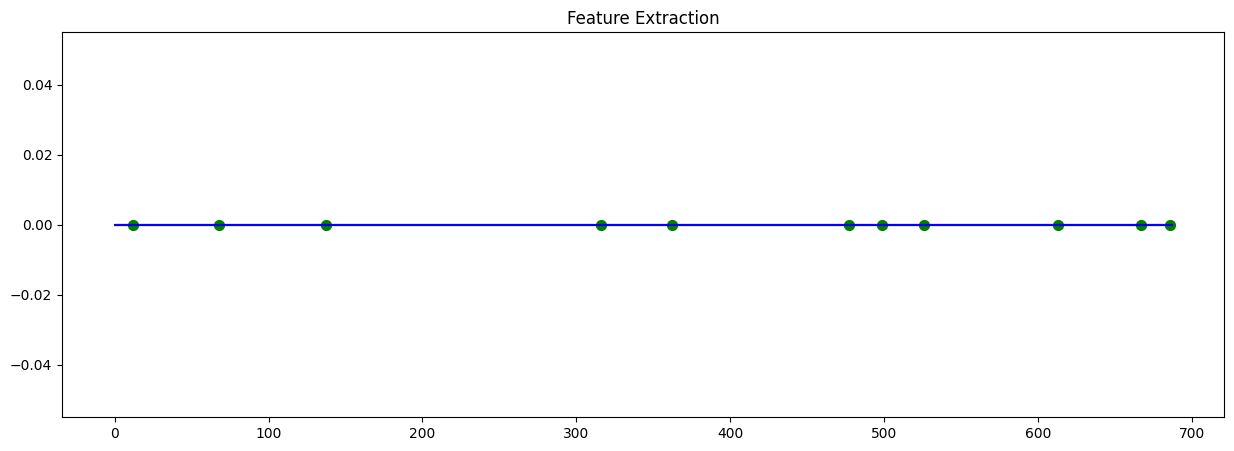

In [118]:
# dim_1 Plotting
plt.figure(figsize=(15,5))
plt.plot(data['Time'], data['dim_1'], c='black')
plt.plot([0, data.shape[0]], [np.percentile(data['dim_1'], 25), np.percentile(data['dim_1'], 25)],c='red')
plt.plot([0, data.shape[0]], [np.percentile(data['dim_1'], 75), np.percentile(data['dim_1'], 75)],c='blue')
plt.scatter(data['Time'][data['Label'] == 1], data['dim_1'][data['Label'] == 1], s=50, c='green')
plt.title("Feature Extraction")
plt.show()

In [119]:
data[['dim_1', 'lof_score', 'IF_score']]

,dim_1,lof_score,IF_score
0,-0.0,0.006702,0.081653
1,-0.0,0.005950,0.110344
2,-0.0,0.023519,0.152744
3,-0.0,0.008254,0.043350
4,-0.0,0.013839,0.147906
...,...,...,...
682,-0.0,0.043580,0.363031
683,-0.0,0.004379,0.027248
684,-0.0,0.023241,0.232406
685,-0.0,0.007993,0.900804


In [120]:
result_scale = data[['dim_1', 'lof_score', 'IF_score']]

In [121]:
result_scale

,dim_1,lof_score,IF_score
0,-0.0,0.006702,0.081653
1,-0.0,0.005950,0.110344
2,-0.0,0.023519,0.152744
3,-0.0,0.008254,0.043350
4,-0.0,0.013839,0.147906
...,...,...,...
682,-0.0,0.043580,0.363031
683,-0.0,0.004379,0.027248
684,-0.0,0.023241,0.232406
685,-0.0,0.007993,0.900804


In [122]:
from sklearn.preprocessing import MinMaxScaler
# Scaling
scaler = MinMaxScaler().fit(result_scale)
result_scal = scaler.transform(result_scale)
result_scal = pd.DataFrame(result_scal, columns=result_scale.columns)

In [123]:
result_scal.describe()

,dim_1,lof_score,IF_score
count,687.0,687.000000,687.000000
mean,0.0,0.014881,0.125753
std,0.0,0.057038,0.131564
min,0.0,0.000000,0.000000
25%,0.0,0.005206,0.055303
50%,0.0,0.007279,0.093791
75%,0.0,0.011315,0.151259
max,0.0,1.000000,1.000000


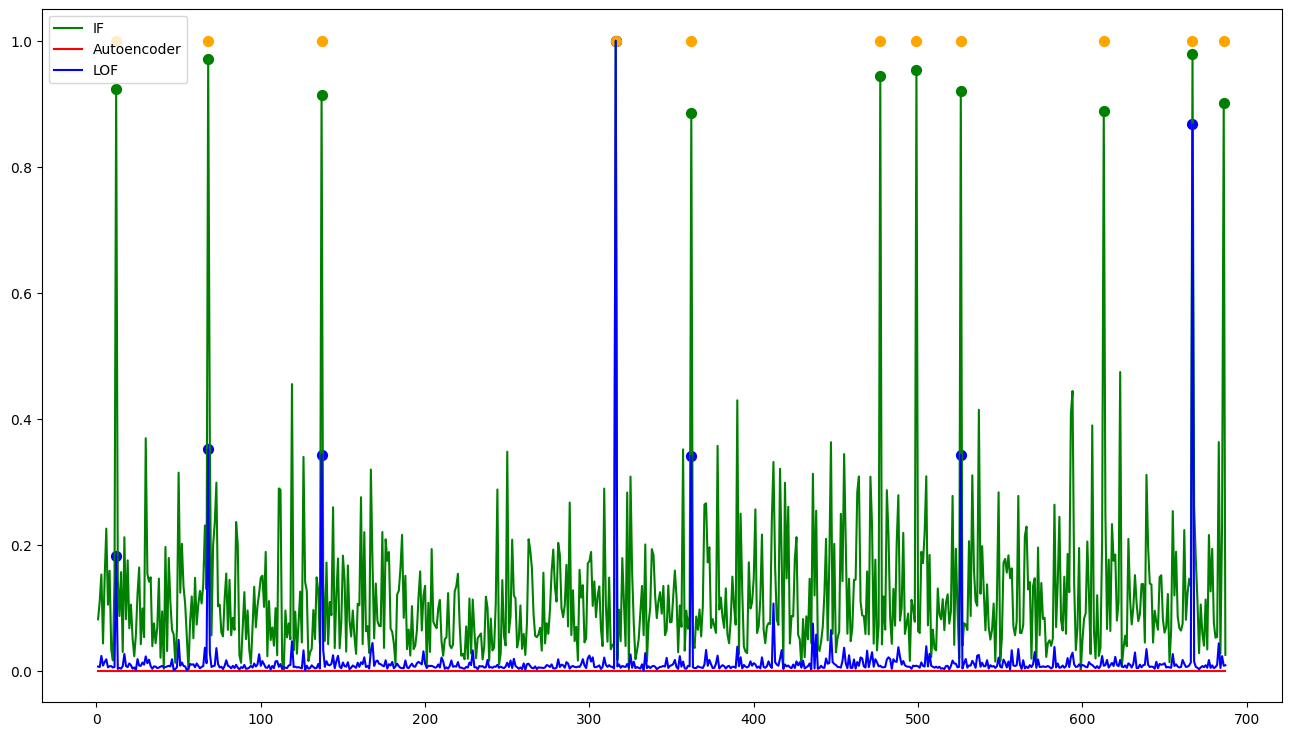

In [124]:
# Result Plotting
plt.figure(figsize=(16,9))
plt.plot(data['Time'], result_scal['IF_score'], c='green', label='IF')
plt.scatter(data['Time'][data['IF_score'] >= 0.5], data['IF_score'][data['IF_score'] >= 0.5], s=50, c='green')
plt.plot(data['Time'], result_scal['dim_1'], c='red', label='Autoencoder')
#plt.scatter(data['Time'][data['dim_1'] >= 0.4], data['dim_1'][data['dim_1'] >= 0.4], s=50, c='red')
plt.plot(data['Time'], result_scal['lof_score'], c='blue', label='LOF')
plt.scatter(data['Time'][data['lof_score'] >= 0.18], data['lof_score'][data['lof_score'] >= 0.18], s=50, c='blue')
plt.scatter(data['Time'][data['Label'] == 1], data['Label'][data['Label'] == 1], s=50, c='orange')
plt.legend()
plt.show()